# 📊 Stage 1: EDA & Product Analytics

**Role:** Junior Data Analyst

**Context:** You are a Data Analyst at the "Superstore" retail company. The Commercial Director has handed you a historical sales dataset and asked you to find growth opportunities, as well as prepare the data for subsequent loading into the corporate data warehouse.

**Technical Requirements:** To prove your data wrangling skills, you must explicitly demonstrate the use of the following `pandas` and `numpy` functions at least once throughout your notebook:
* **Aggregation & Grouping:** `groupby`, `agg`, `nunique`, `transform`
* **Reshaping:** `pivot_table`, `melt`
* **Merging:** `merge` (or `join`)
* **Logic & Binning:** `np.where` (or `np.select`), `pd.qcut` (or `pd.cut`)
* **Time Series & Sorting:** `shift` (or `pct_change`), `rolling`, `nlargest`
* **Filtering & Accessors:** `query`, `.dt` (datetime accessor), `.str` (string accessor), `apply` (or `map`).

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
pd.set_option('display.max_columns', None) #display all collumns
%matplotlib inline

## Step 1. Data Cleaning, Profiling & Feature Engineering
The business does not tolerate data errors. Prepare the dataset for analysis.

1. Load the `Sample - Superstore.csv` dataset into a pandas DataFrame.
2. Bring the DataFrame structure into compliance with Python standards (PEP8).
3. Perform automated exploratory data analysis using any profiling library (e.g., `ydata-profiling`).
4. Check and correct data types. Handle missing values and duplicates.
5. Filter the dataset to exclude any potential test or irrelevant records (e.g., filter only records with positive sales and valid regions).
6. **Feature Engineering:** * Create a new categorical column called `discount_tier` (e.g., 'No Discount', 'Low Discount', 'High Discount') based on the discount size.
   * Extract the day of the week from the order date into a new column.
   * Extract the first word of the `product_name` into a new `brand` column. *(Note: This is a simple string manipulation heuristic. Consider its limitations).*

In [2]:
# load the dataframe
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# df.head()
# df.info()
# df.describe()

# standardized column names according to PEP8 conventions
print(df.columns) #original column names 
df.columns=(
	df.columns
	.str.lower()
	.str.strip()
	.str.replace("-","_")
	.str.replace(" ",'_')
)
print(df.columns) #standardized column names
df.head()

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### -> Data loading and initial inspection
The dataset was successfully loaded. Column names were standardized.

In [3]:
# generate eda report (exploratory data analysis)
profile=ProfileReport(df,explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 90.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
# сheck and convert data types
df.info()

# dates
df['order_date']=pd.to_datetime(df['order_date'])
df['ship_date']=pd.to_datetime(df['ship_date'])

# IDs / names / postal code
df['order_id']=df['order_id'].astype('string')
df['customer_id']=df['customer_id'].astype('string')
df['product_id']=df['product_id'].astype('string')
df['customer_name']=df['customer_name'].astype('string')
df['product_name']=df['product_name'].astype('string')
df['postal_code']=df['postal_code'].astype('string')

# categories
df['ship_mode']=df['ship_mode'].astype('category')
df['segment']=df['segment'].astype('category')
df['country']=df['country'].astype('category')
df['city']=df['city'].astype('category')
df['state']=df['state'].astype('category')
df['region']=df['region'].astype('category')
df['category']=df['category'].astype('category')
df['sub_category']=df['sub_category'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   segment        9994 non-null   object 
 8   country        9994 non-null   object 
 9   city           9994 non-null   object 
 10  state          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  category       9994 non-null   object 
 15  sub_category   9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  sales          9994 non-null   float64
 18  quantity

In [ ]:
# check missing values
print(df.isnull().sum())

# check duplicates
print(df.duplicated().sum())

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64
0


In [32]:
# filter records with positive sales
df=df[df['sales']>0]

# filter valid regions
df['region'].unique()
valid_regions=['South', 'West', 'Central', 'East']
df=df[df['region'].isin(valid_regions)]

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,discount_tier,day_of_week,brand
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,No Discount,Tuesday,Bush
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,No Discount,Tuesday,Hon
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,No Discount,Sunday,Self-Adhesive
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,Low Discount,Sunday,Bretford
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Low Discount,Sunday,Eldon


In [33]:
# create a new column 'discount_tier'
df['discount'].unique()
def get_discount_tier(x):
	if x == 0:
		return 'No Discount'
	elif x <= 0.5:
		return 'Low Discount'
	else:
		return 'High Discount'
df['discount_tier']=df['discount'].apply(get_discount_tier)

# create a new column "day_of_week"
df['day_of_week']=df['order_date'].dt.day_name()

# create a new column "brand"
df['brand']=df['product_name'].str.split().str[0]
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,discount_tier,day_of_week,brand
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,No Discount,Tuesday,Bush
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,No Discount,Tuesday,Hon
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,No Discount,Sunday,Self-Adhesive
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,Low Discount,Sunday,Bretford
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Low Discount,Sunday,Eldon


In [ ]:
# Descriptive statistics overview (Insights 1,2,3)
df.describe()

,row_id,order_date,ship_date,sales,quantity,discount,profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,623.245101,2.225110,0.206452,234.260108


In [ ]:
# Discount distribution (Insight 4)
df['discount_tier'].value_counts()

discount_tier
No Discount      4798
Low Discount     4340
High Discount     856
Name: count, dtype: int64

In [ ]:
# Total sales by region (Insight 5)
df.groupby('region')['sales'].sum().sort_values(ascending=False)

/var/folders/j_/3tk0r8pj30zf6jyhvhm0jr380000gn/T/ipykernel_56793/2733612286.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('region')['sales'].sum().sort_values(ascending=False)


region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64

In [ ]:
# Segment breakdown in % (Insight 6)
df['segment'].value_counts(normalize=True)*100

segment
Consumer       51.941165
Corporate      30.218131
Home Office    17.840704
Name: proportion, dtype: float64

In [ ]:
# List of countries (Insight 7)
df['country'].unique()

['United States']
Categories (1, object): ['United States']

In [ ]:
# City distribution (%) (Insight 8)
df['city'].value_counts(normalize=True)*100

city
New York City    9.155493
Los Angeles      7.474485
Philadelphia     5.373224
San Francisco    5.103062
Seattle          4.282570
                   ...   
Redwood City     0.010006
Holyoke          0.010006
Redding          0.010006
Iowa City        0.010006
Aberdeen         0.010006
Name: proportion, Length: 531, dtype: float64

In [54]:
# State distribution (%) (Insight 9)
df['state'].value_counts(normalize=True)*100

state
California              20.022013
New York                11.286772
Texas                    9.855914
Pennsylvania             5.873524
Washington               5.063038
Illinois                 4.922954
Ohio                     4.692816
Florida                  3.832299
Michigan                 2.551531
North Carolina           2.491495
Virginia                 2.241345
Arizona                  2.241345
Georgia                  1.841105
Tennessee                1.831099
Colorado                 1.821093
Indiana                  1.490895
Kentucky                 1.390835
Massachusetts            1.350810
New Jersey               1.300780
Oregon                   1.240744
Wisconsin                1.100660
Maryland                 1.050630
Delaware                 0.960576
Minnesota                0.890534
Connecticut              0.820492
Oklahoma                 0.660396
Missouri                 0.660396
Alabama                  0.610366
Arkansas                 0.600360
Rhode Is

In [56]:
# Category distribution (%) (Insight 9)
df['category'].value_counts(normalize=True)*100

category
Office Supplies    60.296178
Furniture          21.222734
Technology         18.481089
Name: proportion, dtype: float64

In [58]:
# Sub-Category distribution (%) (Insight 10)
df['sub_category'].value_counts(normalize=True)*100

sub_category
Binders        15.239143
Paper          13.708225
Furnishings     9.575745
Phones          8.895337
Storage         8.465079
Art             7.964779
Accessories     7.754653
Chairs          6.173704
Appliances      4.662798
Labels          3.642185
Tables          3.191915
Envelopes       2.541525
Bookcases       2.281369
Fasteners       2.171303
Supplies        1.901141
Machines        1.150690
Copiers         0.680408
Name: proportion, dtype: float64

In [ ]:
#  Day-of-week distribution (Insight 11)
df['day_of_week'].value_counts()

day_of_week
Monday       1871
Friday       1818
Sunday       1710
Saturday     1655
Thursday     1463
Tuesday      1106
Wednesday     371
Name: count, dtype: int64

In [ ]:
#  Brand distribution (Insight 12)
df['brand'].value_counts()

brand
Xerox         865
Avery         553
GBC           332
Global        284
Newell        276
             ... 
Wasp            1
Park            1
I.R.I.S         1
Multimedia      1
Penpower        1
Name: count, Length: 478, dtype: int64

> 💡 **Business Reflection:**
> Write down at least 5 main anomalies or insights you noticed in the raw data (e.g., outliers, missing values, illogical values, class imbalance). Why do you think extracting features like "day of the week" or "brand" might be valuable for the Sales Director, despite the potential inaccuracies of a simple "first word" extraction?

**Your answer here:**

Part 1
1. Most sales are small (median = 54), but a few very large orders increase the average (mean = 229). The high variation in sales (std = 623) shows that order values are very different. This means most revenue comes from a small number of big purchases.
2. Profit has extreme outliers, ranging from large losses (-6599) to very high profits (8399), indicating unstable profitability across orders.
3. Most customers buy only a few items per order (around 3–4), with rare bulk purchases up to 14 items.
4. Almost half of all orders (48%) are made without any discount, indicating that discounts are not always necessary to drive sales.
5. Sales vary by region: West (725k) and East (678k) perform best, while South (391k) has the lowest sales and growth potential.
6. Most customers are Consumers (52%), while Corporate (30%) and Home Office (18%) are smaller segments. This shows the business is mainly driven by individual customers.
7. Sales are only from the US, so regional performance is compared within one market.
8. Sales is highly concentrated in a few major cities, especially New York City and Los Angeles.
9. Office Supplies dominates the dataset (60%), showing class imbalance.
10. Binders and Paper dominate sales (15% and 14%), making them the top-performing product sub-categories.
11. Most activity happens on Monday and Friday, while Wednesday is the lowest. Sales are uneven across the week.
12. Brand Xerox stands out as the clear leader, while all other brands have lower shares.

Part 2
1. Day of the week helps the Sales Director understand when customers buy more or less, so they can plan promotions, staffing, or campaigns more effectively.
2. Brand can show which manufacturers are most popular and profitable.
3. Even if the first-word is not always accurate, it can still show useful patterns and trends, which is better than having no insight.

## Step 2. Visual EDA
Answer basic business questions using static visualizations (`matplotlib` / `seaborn`). **Do not just build random charts; choose the visual encoding that best answers the specific question.**

1. **Margin Analysis:** Analyze the profit margins across different product categories. Choose an appropriate chart type that clearly displays not just the average profit, but the full distribution of transactions and the presence of extreme outliers (losses).
2. **Trend and Noise Reduction:** Visualize the dynamics of the company's revenue over time. Since raw daily data is highly volatile and noisy, apply a data transformation technique before plotting to smooth the visual trend, ensuring top management can clearly see the underlying trajectory without getting distracted by daily spikes.
3. **Metric Comparison:** Compare total Sales and total Profit simultaneously across different regions or years. Transform your dataset's structure as needed to feed it into a single, clean chart that allows easy side-by-side comparison of these two distinct metrics.

<Figure size 640x480 with 0 Axes>

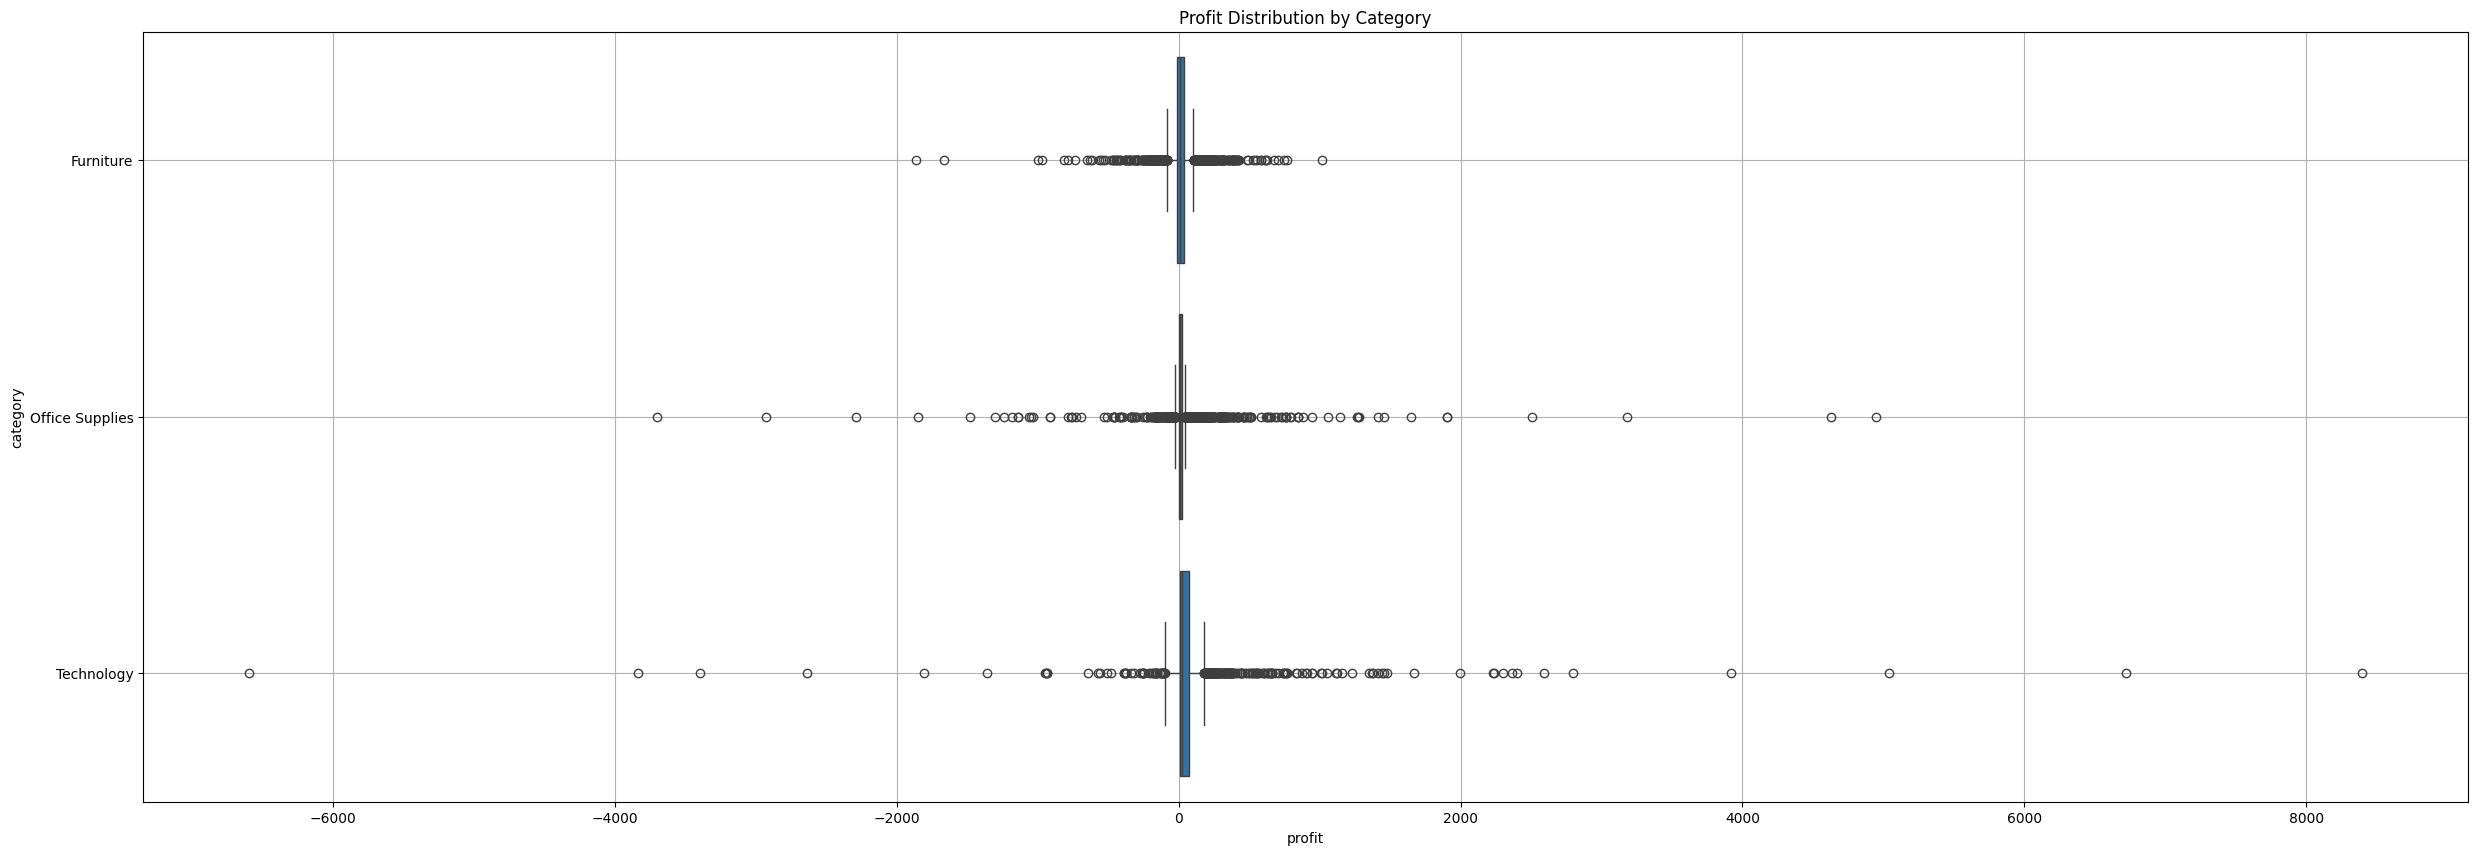

In [ ]:
plt.clf()
plt.figure(figsize=(30,10))
sns.boxplot(data=df, x='profit', y='category')
plt.title('Profit Distribution by Category')
plt.grid(True)
plt.show()

In [81]:
df.groupby("category")["profit"].describe()

/var/folders/j_/3tk0r8pj30zf6jyhvhm0jr380000gn/T/ipykernel_56793/1722489308.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("category")["profit"].describe()


,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Furniture,2121.0,8.699327,136.049246,-1862.3124,-12.84900,7.7748,33.7266,1013.127
Office Supplies,6026.0,20.327050,164.887280,-3701.8928,2.10150,6.8824,19.4163,4946.370
Technology,1847.0,78.752002,428.816633,-6599.9780,5.20365,25.0182,74.8946,8399.976


1. BOXPLOT

The boxplot clearly shows general descriptive statictics such as the median, spread, outliers. It helps to understand how profit is distributed within each category.

Based on the boxplot, profit distribution varies significantly across product categories. All categories have median close to zero. It indicates that most of products generate small profit.

But the categories show the next different patterns:
- Furniture has the weakest performance with frequent losses.
- Office Supplies is relatively more stable compared to other categories.
- Technology shows the highest variability. It has large profits but also extreme losses. 

In [102]:
daily_sales=df.groupby('order_date')['sales'].sum()
smoothed=daily_sales.rolling(window=7).mean()

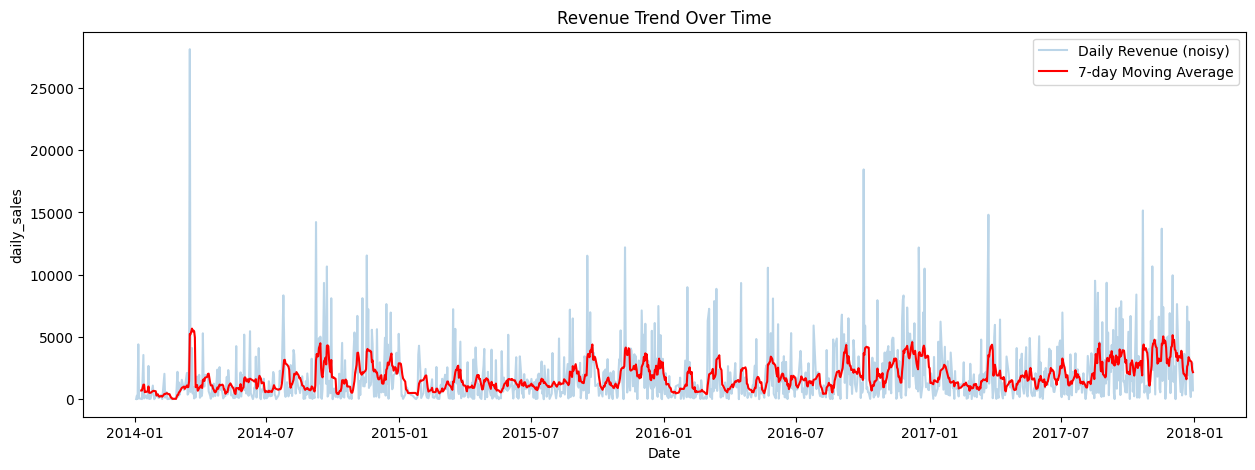

In [108]:
plt.figure(figsize=(15,5))
plt.plot(daily_sales, alpha=0.3, label='Daily Revenue (noisy)')
plt.plot(smoothed, color='red', label='7-day Moving Average')
plt.title("Revenue Trend Over Time")
plt.xlabel("Date")
plt.ylabel("daily_sales")
plt.legend()
plt.show()

The daily revenue is very noisy due to fluctuations in sales. To reduce noise, a 7-day moving average was applied. This helps to show the overall trend more clearly.

In [105]:
df_region=df.groupby('region')[['sales','profit']].sum()
df_region

/var/folders/j_/3tk0r8pj30zf6jyhvhm0jr380000gn/T/ipykernel_56793/2976391205.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_region=df.groupby('region')[['sales','profit']].sum()


,sales,profit
region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


In [ ]:
df_melt = df_region.reset_index().melt(
    id_vars="region",
    value_vars=["sales", "profit"],
    var_name="metric",
    value_name="value"
)
df_melt

,region,metric,value
0,Central,sales,501239.8908
1,East,sales,678781.2400
2,South,sales,391721.9050
3,West,sales,725457.8245
4,Central,profit,39706.3625
5,East,profit,91522.7800
6,South,profit,46749.4303
7,West,profit,108418.4489


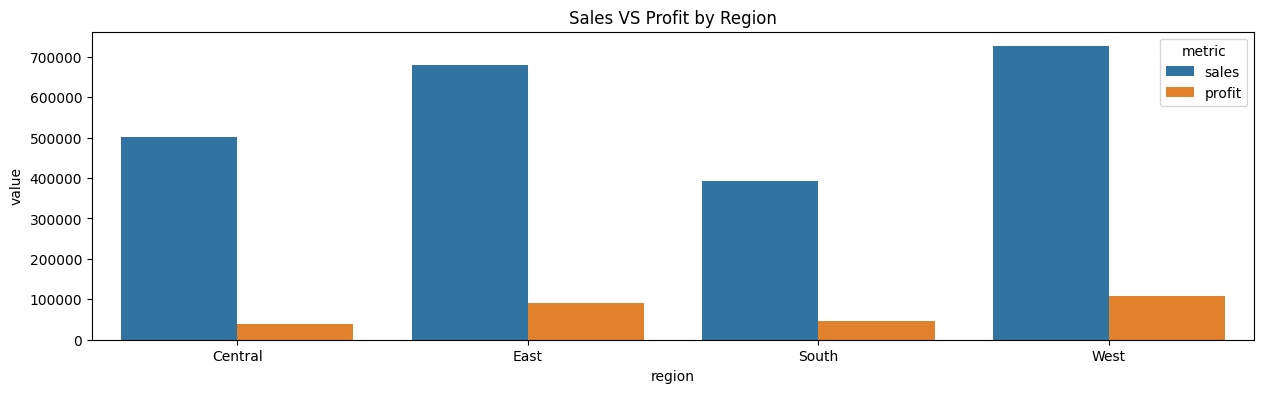

In [110]:
plt.figure(figsize=(15,4))
sns.barplot(data=df_melt,x="region", y="value", hue="metric")
plt.title('Sales VS Profit by Region')
plt.show()

> 💡 **Business Reflection:**
> Describe any seasonal patterns you observe in the trend chart. If they exist, suggest potential reasons based on external factors or business cycles. If not, explain why they might be absent in this specific dataset.

**Your answer here:**
> 🛠 **Technical Reflection:**
> Visualization libraries like Seaborn often require data to be in a "long" (tidy) format. Explain what this means and why it is more convenient for plotting multiple metrics. Which method did you use to transform your data for the comparison chart (if any), and why?

**Your answer here:**

## Step 3. Interactive Visualization & Data Enrichment (Plotly)
The Regional Director has asked for interactive charts for an upcoming presentation.

1. **Data Enrichment:** Create a small supplementary dictionary or DataFrame containing Regional Managers (e.g., West: Anna, East: John, Central: Michael, South: Sarah). Combine this data with your main transaction dataset so every row has a Manager assigned.
2. **Geographical Visualization:** Build an interactive geographical chart that allows the user to hover over different US states and see their total sales volume.
3. **Hierarchical Visualization:** Revenue isn't flat. Create an interactive chart that effectively displays the part-to-whole relationship and allows the user to drill down through multiple levels of granularity: from **Manager** -> to **Region** -> to **Category**.

In [9]:
# Your code for Step 3 goes here

> 💡 **Business Reflection:**
> Based on your hierarchical chart, which Manager has the most problematic sub-category (e.g., largest total loss or lowest profit margin)? If you were this Manager, what immediate actions would you take regarding pricing or inventory?

**Your answer here:**
> 🛠 **Technical Reflection:**
> Briefly explain the differences between pd.merge(), DataFrame.join(), and Series.map(). Which approach did you choose to add the Managers to your dataset, and why?

**Your answer here:**

## Step 4. Product & Customer Analytics
It's time to dig deeper and look at our customers' behavior.

1. **Core Metrics:** Group the data and visualize the monthly dynamics of key e-commerce metrics: **AOV** (Average Order Value) and **ARPU** (Average Revenue Per User).
2. **Cohort Analysis (Retention):** Build a customer retention matrix (Customer Retention Rate) by the month of their first purchase.
3. **RFM Segmentation:** * Calculate the R (Recency), F (Frequency), and M (Monetary) metrics for each unique customer.
   * Develop a scoring methodology (e.g., a quantile-based approach from 1 to 3, or 1 to 5).
   * Based on the scoring, assign customers to clear business segments (e.g., "Champions", "At Risk", "Sleeping", "Newbies").
   * Output the top 5 customers in each key segment.

In [10]:
# Your code for Step 4 goes here

> 💡 **Business Reflection:**
> * At what month after the first purchase do we lose the majority of our new customers based on your cohort matrix?
> * Write a brief action plan: What specific email campaign or promo action would you suggest sending to the "Champions" segment vs. the "At Risk" segment to maximize profit?

**Your answer here:**
> 🛠 **Technical Reflection:**
> * Compare the performance and readability of different ways to create categorical columns in pandas: `for` loops, the `.apply()` method, and vectorized functions (like `np.where`, `np.select`, or `pd.cut`). Which approach did you use for the `discount_tier` and RFM segmentation, and why?
> * When calculating the first purchase date for cohort analysis, explain the difference in output shape between using `.transform('min')` and `.groupby().min()`. Which one is more suitable for adding a new column directly to the original dataframe?

**Your answer here:**

## Step 5. Export Results for Validation

Save your cleaned dataset and RFM results to CSV.

📤 **Handoff to Stage 2:**  
Your CSV files will be used by the Data Engineering team to validate their SQL-based calculations.

In [11]:
# Your code for Step 5 goes here